# EDA — B2W-Reviews01 como feedback real

Este notebook analisa avaliações reais de e-commerce em PT-BR. Não cria nem utiliza rótulos de intenção; a classificação de intenções usa o Bitext.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
RAW = ROOT / 'data/raw/b2w-reviews01/B2W-Reviews01.csv'
assert RAW.exists(), 'O arquivo B2W-Reviews01.csv não foi encontrado.'
raw = pd.read_csv(RAW)
raw.head()

/var/folders/jc/cv3hf9w534d9rw3hzkw2nrh00000gn/T/ipykernel_18099/917045826.py:11: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  raw = pd.read_csv(RAW)


,submission_date,reviewer_id,product_id,product_name,product_brand,site_category_lv1,site_category_lv2,review_title,overall_rating,recommend_to_a_friend,review_text,reviewer_birth_year,reviewer_gender,reviewer_state
0,2018-01-01 00:11:28,d0fb1ca69422530334178f5c8624aa7a99da47907c44de...,132532965,Notebook Asus Vivobook Max X541NA-GO472T Intel...,NaN,Informática,Notebook,Bom,4,Yes,Estou contente com a compra entrega rápida o ú...,1958.0,F,RJ
1,2018-01-01 00:13:48,014d6dc5a10aed1ff1e6f349fb2b059a2d3de511c7538a...,22562178,Copo Acrílico Com Canudo 500ml Rocie,NaN,Utilidades Domésticas,"Copos, Taças e Canecas","Preço imbatível, ótima qualidade",4,Yes,"Por apenas R$1994.20,eu consegui comprar esse ...",1996.0,M,SC
2,2018-01-01 00:26:02,44f2c8edd93471926fff601274b8b2b5c4824e386ae4f2...,113022329,Panela de Pressão Elétrica Philips Walita Dail...,philips walita,Eletroportáteis,Panela Elétrica,ATENDE TODAS AS EXPECTATIVA.,4,Yes,SUPERA EM AGILIDADE E PRATICIDADE OUTRAS PANEL...,1984.0,M,SP
3,2018-01-01 00:35:54,ce741665c1764ab2d77539e18d0e4f66dde6213c9f0863...,113851581,Betoneira Columbus - Roma Brinquedos,roma jensen,Brinquedos,Veículos de Brinquedo,presente mais que desejado,4,Yes,MEU FILHO AMOU! PARECE DE VERDADE COM TANTOS D...,1985.0,F,SP
4,2018-01-01 01:00:28,7d7b6b18dda804a897359276cef0ca252f9932bf4b5c8e...,131788803,"Smart TV LED 43"" LG 43UJ6525 Ultra HD 4K com C...",lg,TV e Home Theater,TV,"Sem duvidas, excelente",5,Yes,"A entrega foi no prazo, as americanas estão de...",1994.0,M,MG


## 1. Estrutura e limpeza

A limpeza remove somente textos vazios e duplicatas exatas. Nenhuma categoria é inferida.

In [2]:
df = raw.copy()
title = df['review_title'].fillna('').astype(str)
body = df['review_text'].fillna('').astype(str)
df['feedback_text'] = (title + ' ' + body).map(lambda value: ' '.join(value.split()))
without_empty = df[df['feedback_text'].ne('')].copy()
df = without_empty.drop_duplicates().copy()
df['submission_date'] = pd.to_datetime(df['submission_date'], errors='coerce')
df['text_length_chars'] = df['feedback_text'].str.len()
print({'raw': len(raw), 'empty_text_removed': len(raw)-len(without_empty), 'duplicates_removed': len(without_empty)-len(df), 'final': len(df)})
display(df.dtypes.to_frame('dtype'))
display(df.isna().sum().to_frame('ausentes'))
df.head()

{'raw': 132373, 'empty_text_removed': 72, 'duplicates_removed': 954, 'final': 131347}


,dtype
submission_date,datetime64[ns]
reviewer_id,object
product_id,object
product_name,object
product_brand,object
site_category_lv1,object
site_category_lv2,object
review_title,object
overall_rating,int64
recommend_to_a_friend,object


,ausentes
submission_date,0
reviewer_id,0
product_id,0
product_name,83
product_brand,90556
site_category_lv1,6
site_category_lv2,3978
review_title,226
overall_rating,0
recommend_to_a_friend,18


,submission_date,reviewer_id,product_id,product_name,product_brand,site_category_lv1,site_category_lv2,review_title,overall_rating,recommend_to_a_friend,review_text,reviewer_birth_year,reviewer_gender,reviewer_state,feedback_text,text_length_chars
0,2018-01-01 00:11:28,d0fb1ca69422530334178f5c8624aa7a99da47907c44de...,132532965,Notebook Asus Vivobook Max X541NA-GO472T Intel...,NaN,Informática,Notebook,Bom,4,Yes,Estou contente com a compra entrega rápida o ú...,1958.0,F,RJ,Bom Estou contente com a compra entrega rápida...,162
1,2018-01-01 00:13:48,014d6dc5a10aed1ff1e6f349fb2b059a2d3de511c7538a...,22562178,Copo Acrílico Com Canudo 500ml Rocie,NaN,Utilidades Domésticas,"Copos, Taças e Canecas","Preço imbatível, ótima qualidade",4,Yes,"Por apenas R$1994.20,eu consegui comprar esse ...",1996.0,M,SC,"Preço imbatível, ótima qualidade Por apenas R$...",102
2,2018-01-01 00:26:02,44f2c8edd93471926fff601274b8b2b5c4824e386ae4f2...,113022329,Panela de Pressão Elétrica Philips Walita Dail...,philips walita,Eletroportáteis,Panela Elétrica,ATENDE TODAS AS EXPECTATIVA.,4,Yes,SUPERA EM AGILIDADE E PRATICIDADE OUTRAS PANEL...,1984.0,M,SP,ATENDE TODAS AS EXPECTATIVA. SUPERA EM AGILIDA...,258
3,2018-01-01 00:35:54,ce741665c1764ab2d77539e18d0e4f66dde6213c9f0863...,113851581,Betoneira Columbus - Roma Brinquedos,roma jensen,Brinquedos,Veículos de Brinquedo,presente mais que desejado,4,Yes,MEU FILHO AMOU! PARECE DE VERDADE COM TANTOS D...,1985.0,F,SP,presente mais que desejado MEU FILHO AMOU! PAR...,89
4,2018-01-01 01:00:28,7d7b6b18dda804a897359276cef0ca252f9932bf4b5c8e...,131788803,"Smart TV LED 43"" LG 43UJ6525 Ultra HD 4K com C...",lg,TV e Home Theater,TV,"Sem duvidas, excelente",5,Yes,"A entrega foi no prazo, as americanas estão de...",1994.0,M,MG,"Sem duvidas, excelente A entrega foi no prazo,...",225


## 2. Notas, recomendação e categorias

As notas e a resposta de recomendação são metadados originais do B2W, úteis para caracterizar a satisfação sem tratá-la como intenção.

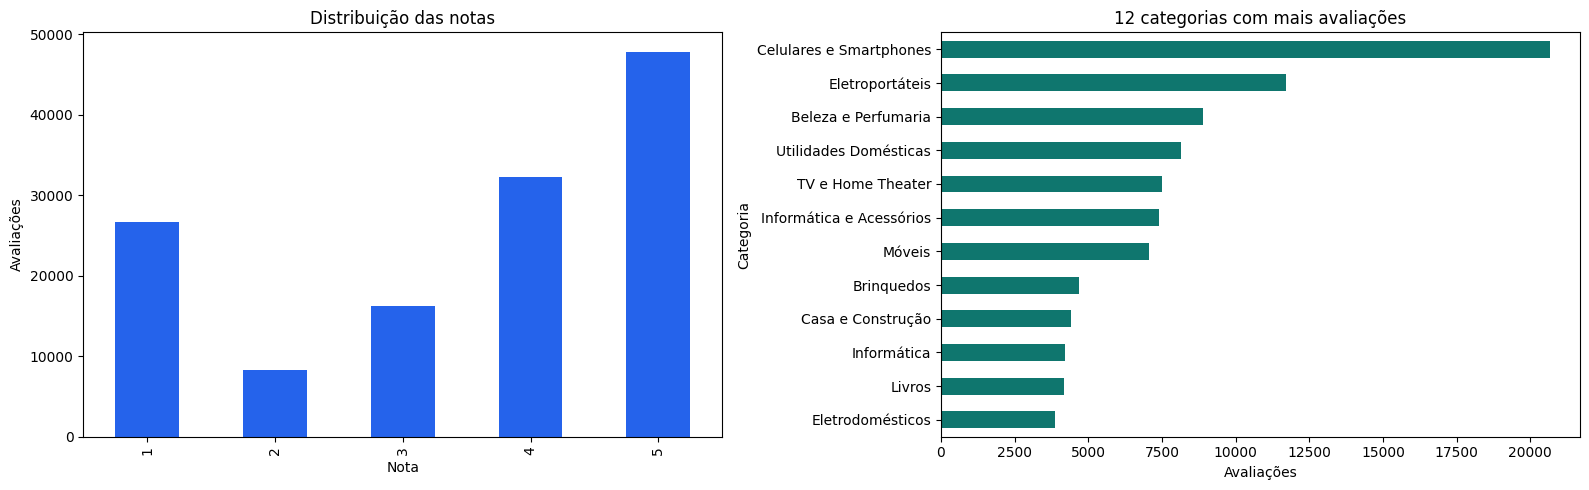

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
df['overall_rating'].value_counts().sort_index().plot.bar(ax=axes[0], color='#2563eb')
axes[0].set(title='Distribuição das notas', xlabel='Nota', ylabel='Avaliações')
df['site_category_lv1'].value_counts().head(12).sort_values().plot.barh(ax=axes[1], color='#0f766e')
axes[1].set(title='12 categorias com mais avaliações', xlabel='Avaliações', ylabel='Categoria')
plt.tight_layout()

## 3. Tempo e comprimento textual

Investigamos volume mensal e extensão dos textos por nota. Isso ajuda a entender o comportamento do feedback sem introduzir rótulos artificiais.

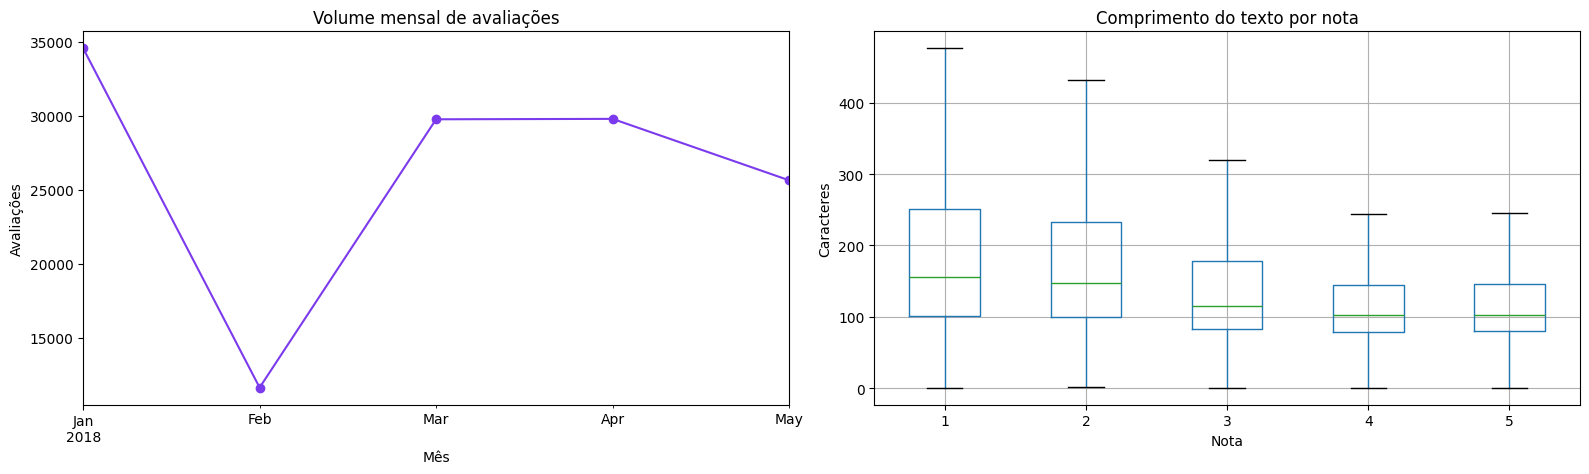

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
df.dropna(subset=['submission_date']).set_index('submission_date').resample('ME').size().plot(marker='o', ax=axes[0], color='#7c3aed')
axes[0].set(title='Volume mensal de avaliações', xlabel='Mês', ylabel='Avaliações')
df.boxplot(column='text_length_chars', by='overall_rating', showfliers=False, ax=axes[1])
axes[1].set(title='Comprimento do texto por nota', xlabel='Nota', ylabel='Caracteres')
plt.suptitle('')
plt.tight_layout()

## 4. Hipóteses

1. As notas 4 e 5 predominam.
2. Avaliações negativas tendem a ser mais longas.
3. Poucas categorias concentram grande parte do volume.
4. A recomendação a amigos acompanha a satisfação geral.

In [5]:
recommend = df['recommend_to_a_friend'].dropna().astype(str).str.lower()
summary = {
    'notas 4 e 5': f"{df['overall_rating'].isin([4, 5]).mean():.2%}",
    'mediana caracteres — notas 1 e 2': int(df[df['overall_rating'].isin([1, 2])]['text_length_chars'].median()),
    'mediana caracteres — notas 4 e 5': int(df[df['overall_rating'].isin([4, 5])]['text_length_chars'].median()),
    'participação das cinco maiores categorias': f"{df['site_category_lv1'].value_counts().head(5).sum()/len(df):.2%}",
    'recomendação positiva': f"{recommend.isin(['yes', 'sim']).mean():.2%}",
    'período': f"{df['submission_date'].min().date()} a {df['submission_date'].max().date()}",
}
pd.Series(summary, name='evidência')

notas 4 e 5                                                   60.99%
mediana caracteres — notas 1 e 2                                 154
mediana caracteres — notas 4 e 5                                 102
participação das cinco maiores categorias                     43.35%
recomendação positiva                                         73.15%
período                                      2018-01-01 a 2018-05-31
Name: evidência, dtype: object

## Conclusão

O B2W fornece feedback real para EDA e análise de satisfação. Para classificação de intenção, use o notebook `04_bitext_intent_eda.ipynb` e o campo `intent` original do Bitext.